In [1]:
import sys
sys.path.append('../utils')
from utils_models import *
from scipy.optimize import minimize

In [23]:
EJ = 4
EC = 4/5.9
EL = 4/29.2
fluxonium = scqubits.Fluxonium(EJ=EJ,
                        EC=EC,
                        EL=EL,
                        flux=0,cutoff=110,
                        truncated_dim=20)
freq = {
    'g0g1':[],
    'e0e1':[],
    'f0f1':[],
    'g1g2':[],
    'e1e2':[],
    'f1f2':[]
}

me = {
    'g1g2':[],
    'e1e2':[],
    'f1f2':[]
}

tmon_freq = []
for t_EJ in tqdm(np.linspace(10,50,200)):


    transmon = scqubits.Transmon(
        EJ=t_EJ,
        EC=0.2,
        ng=0.0,
        ncut=10,
        truncated_dim = 4
        )

    system = FluxoniumTransmonSystem(
        fluxonium  = fluxonium,
        transmon = transmon,
        computaional_states = '1,2',
        g_strength = 0.1,
        )

    def dressed_ener(ql,ol):
        return system.evals[system.product_to_dressed[(ql,ol)]]
    ols = system.transmon.truncated_dim
    op = system.hilbertspace.op_in_dressed_eigenbasis(transmon.n_operator)

    tmon_freq.append(transmon.eigenvals()[1]-transmon.eigenvals()[0])
    freq['g1g2'].append(dressed_ener(0,2)-dressed_ener(0,1))
    freq['e1e2'].append(dressed_ener(1,2)-dressed_ener(1,1))
    freq['f1f2'].append(dressed_ener(2,2)-dressed_ener(2,1))

    freq['g0g1'].append(dressed_ener(0,1)-dressed_ener(0,0))
    freq['e0e1'].append(dressed_ener(1,1)-dressed_ener(1,0))
    freq['f0f1'].append(dressed_ener(2,1)-dressed_ener(2,0))

    me['g1g2'].append(abs(op[system.product_to_dressed[(0,1)],  system.product_to_dressed[(0,2)]]))
    me['e1e2'].append(abs(op[system.product_to_dressed[(1,1)],  system.product_to_dressed[(1,2)]]))
    me['f1f2'].append(abs(op[system.product_to_dressed[(2,1)],  system.product_to_dressed[(2,2)]]))


100%|██████████| 200/200 [00:29<00:00,  6.70it/s]


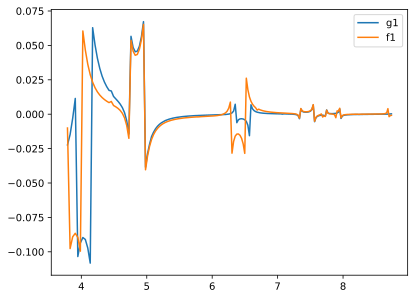

In [24]:
# plt.plot(np.array(tmon_freq),np.array(freq['g0g1'])-np.array(freq['e0e1']),label='g0')
# plt.plot(np.array(tmon_freq),np.array(freq['f0f1'])-np.array(freq['e0e1']),label='f0')

plt.plot(np.array(tmon_freq),np.array(freq['g1g2'])-np.array(freq['e1e2']),label='g1')
plt.plot(np.array(tmon_freq),np.array(freq['f1f2'])-np.array(freq['e1e2']),label='f1')

plt.legend()

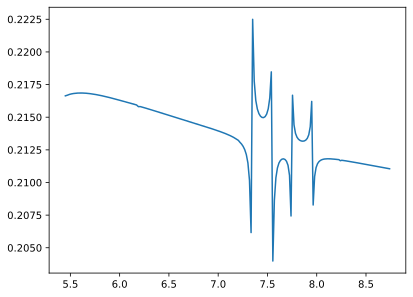

In [14]:
plt.plot(np.array(tmon_freq),np.array(freq['e0e1'])-np.array(freq['e1e2']),label='f1')


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\varphi$', ylabel='Re $\\psi_j(\\varphi)$,  energy [GHz]'>)

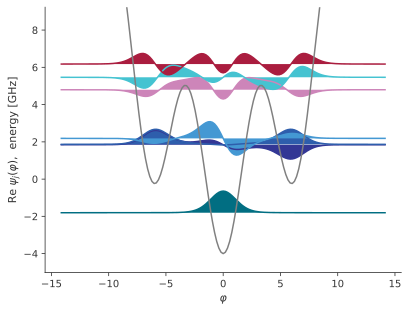

In [45]:
light = scqubits.Fluxonium(EJ=4,
                        EC=4/6,
                        EL=4/20,
                        flux=0,cutoff=110,
                        truncated_dim=20)

light.plot_wavefunction(which=[0,1,2,3,4,5,6])